In [ ]:
# Cell 1 — Cek GPU
!nvidia-smi

Fri Jul  3 14:48:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   36C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Cell 2 — Cek RAM dan Disk Colab
!free -h
!df -h

               total        used        free      shared  buff/cache   available
Mem:            52Gi       1.1Gi        48Gi       2.0Mi       3.6Gi        51Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   66G  42% /
tmpfs            64M     0   64M   0% /dev
shm              26G     0   26G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/nvme0n1p1  119G   52G   68G  44% /kaggle/input
tmpfs            27G  100K   27G   1% /var/colab
tmpfs            27G     0   27G   0% /proc/acpi
tmpfs            27G     0   27G   0% /proc/scsi
tmpfs            27G     0   27G   0% /sys/firmware


In [ ]:
# Cell 3 — Install Ultralytics YOLO
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.4 MB/s eta 0:00:00


In [ ]:
# Cell 4 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 5 — Konfigurasi Utama Revisi
from pathlib import Path
import os
import shutil
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# KONFIGURASI FILE DAN FOLDER
# ==========================================================

# Dataset ZIP tetap dibaca dari Google Drive
ZIP_PATH = Path("/content/drive/MyDrive/Colab Notebooks/Dataset_Tomat_YOLO.zip")

# Dataset hasil extract disimpan di lokal Colab
WORK_DIR = Path("/content/tomat_dataset")

# Semua hasil training/evaluasi disimpan di lokal Colab, bukan Drive
RESULT_DIR = Path("/content/YOLO_Tomat_Result")

# Nama run baru agar tidak tercampur dengan coba sebelumnya
RUN_NAME = "final_yolo11m_tomat_11class_hardaug_v2"

RUN_DIR = RESULT_DIR / RUN_NAME
ARTIFACT_DIR = RESULT_DIR / f"{RUN_NAME}_artifacts"

# ==========================================================
# KELAS DATASET TERBARU 11 KELAS
# ==========================================================
# Urutan ini harus sama dengan split_dataset_yolo.py dan data.yaml:
# 0  bacterial_spot_leaf
# 1  early_blight_leaf
# 2  healthy_leaf
# 3  late_blight_leaf
# 4  mosaic_virus
# 5  septoria_leaf_spot
# 6  bacterial_spot_fruit
# 7  blossom_end_rot
# 8  catface
# 9  healthy_fruit
# 10 serangan_hama

class_names = [
    "bacterial_spot_leaf",
    "early_blight_leaf",
    "healthy_leaf",
    "late_blight_leaf",
    "mosaic_virus",
    "septoria_leaf_spot",
    "bacterial_spot_fruit",
    "blossom_end_rot",
    "catface",
    "healthy_fruit",
    "serangan_hama"
]

# ==========================================================
# PARAMETER TRAINING
# ==========================================================
# Fokus percobaan ini:
# - bacterial_spot_leaf sudah ditambah data
# - early_blight_leaf dan late_blight_leaf dibantu dengan augmentasi train-only
# - training dibuat lebih stabil agar ciri bercak tidak terlalu rusak

MODEL_NAME = "yolo11m.pt"

EPOCHS = 160
IMGSZ = 832
BATCH = -1
WORKERS = 4
PATIENCE = 35
SEED = 42

# Jangan resume dari run lama karena strategi training berubah
RESUME_IF_AVAILABLE = False

# ==========================================================
# BUAT FOLDER LOKAL COLAB
# ==========================================================

RESULT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("ZIP_PATH:", ZIP_PATH)
print("WORK_DIR:", WORK_DIR)
print("RESULT_DIR:", RESULT_DIR)
print("RUN_DIR:", RUN_DIR)
print("ARTIFACT_DIR:", ARTIFACT_DIR)
print("MODEL_NAME:", MODEL_NAME)
print("EPOCHS:", EPOCHS)
print("IMGSZ:", IMGSZ)
print("BATCH:", BATCH)
print("WORKERS:", WORKERS)
print("PATIENCE:", PATIENCE)
print("Jumlah kelas:", len(class_names))

print("\nDaftar kelas:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

ZIP_PATH: /content/drive/MyDrive/Colab Notebooks/Dataset_Tomat_YOLO.zip
WORK_DIR: /content/tomat_dataset
RESULT_DIR: /content/YOLO_Tomat_Result
RUN_DIR: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2
ARTIFACT_DIR: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts
MODEL_NAME: yolo11m.pt
EPOCHS: 160
IMGSZ: 832
BATCH: -1
WORKERS: 4
PATIENCE: 35
Jumlah kelas: 11

Daftar kelas:
0: bacterial_spot_leaf
1: early_blight_leaf
2: healthy_leaf
3: late_blight_leaf
4: mosaic_virus
5: septoria_leaf_spot
6: bacterial_spot_fruit
7: blossom_end_rot
8: catface
9: healthy_fruit
10: serangan_hama


In [ ]:
# Cell 6 — Cek File ZIP Dataset di Drive
print("Apakah file ZIP ada?", ZIP_PATH.exists())
print("Lokasi ZIP:", ZIP_PATH)

if ZIP_PATH.exists():
    print("Ukuran file:", round(ZIP_PATH.stat().st_size / (1024**3), 2), "GB")
else:
    raise FileNotFoundError(
        "Dataset_Tomat_YOLO.zip tidak ditemukan. "
        "Pastikan file ada di /content/drive/MyDrive/Colab Notebooks/"
    )

Apakah file ZIP ada? True
Lokasi ZIP: /content/drive/MyDrive/Colab Notebooks/Dataset_Tomat_YOLO.zip
Ukuran file: 8.16 GB


In [ ]:
# Cell 7 — Extract Dataset dari Drive ke Lokal Colab
if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)

WORK_DIR.mkdir(parents=True, exist_ok=True)

!unzip -o -q "/content/drive/MyDrive/Colab Notebooks/Dataset_Tomat_YOLO.zip" -d "/content/tomat_dataset"

print("Extract selesai.")

Extract selesai.


In [ ]:
# Cell 8 — Cari Lokasi Dataset YOLO
candidate_paths = [WORK_DIR]

for item in WORK_DIR.rglob("*"):
    if item.is_dir():
        candidate_paths.append(item)

dataset_path = None
data_yaml_path = None

for path in candidate_paths:
    data_yaml = path / "data.yaml"
    images_dir = path / "images"
    labels_dir = path / "labels"

    if data_yaml.exists() and images_dir.exists() and labels_dir.exists():
        dataset_path = path
        data_yaml_path = data_yaml
        break

if dataset_path is None:
    print("Dataset YOLO belum ditemukan.")
    print("Isi folder kerja:")
    for item in WORK_DIR.iterdir():
        print(item)
    raise FileNotFoundError("Struktur dataset YOLO tidak ditemukan.")
else:
    print("Dataset ditemukan di:")
    print(dataset_path)

    print("\nFile data.yaml:")
    print(data_yaml_path)

    print("\nIsi folder dataset:")
    for item in dataset_path.iterdir():
        print(item)

Dataset ditemukan di:
/content/tomat_dataset

File data.yaml:
/content/tomat_dataset/data.yaml

Isi folder dataset:
/content/tomat_dataset/labels
/content/tomat_dataset/data.yaml
/content/tomat_dataset/images


In [ ]:
# Cell 9 — Perbaiki data.yaml untuk 11 Kelas
data_yaml_path = dataset_path / "data.yaml"

yaml_text = f"""
path: {dataset_path}
train: images/train
val: images/val
test: images/test

nc: {len(class_names)}
names:
"""

for i, name in enumerate(class_names):
    yaml_text += f"  {i}: {name}\n"

data_yaml_path.write_text(yaml_text)

print("Isi data.yaml terbaru:")
print(data_yaml_path.read_text())

Isi data.yaml terbaru:

path: /content/tomat_dataset
train: images/train
val: images/val
test: images/test

nc: 11
names:
  0: bacterial_spot_leaf
  1: early_blight_leaf
  2: healthy_leaf
  3: late_blight_leaf
  4: mosaic_virus
  5: septoria_leaf_spot
  6: bacterial_spot_fruit
  7: blossom_end_rot
  8: catface
  9: healthy_fruit
  10: serangan_hama



In [ ]:
# Cell 10 — Cek Jumlah Data Train, Val, Test
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def count_images(folder):
    total = 0

    if not folder.exists():
        return total

    for ext in image_extensions:
        total += len(list(folder.glob(f"*{ext}")))
        total += len(list(folder.glob(f"*{ext.upper()}")))

    return total


print("Rekap dataset YOLO:")

for split in ["train", "val", "test"]:
    image_dir = dataset_path / "images" / split
    label_dir = dataset_path / "labels" / split

    image_count = count_images(image_dir)
    label_count = len(list(label_dir.glob("*.txt"))) if label_dir.exists() else 0

    print(f"{split}: {image_count} gambar, {label_count} label")

Rekap dataset YOLO:
train: 2585 gambar, 2585 label
val: 319 gambar, 319 label
test: 330 gambar, 330 label


In [ ]:
# Cell 11 — Cek Distribusi Class ID
from collections import Counter

class_counter = Counter()
invalid_label_files = []

for split in ["train", "val", "test"]:
    label_dir = dataset_path / "labels" / split

    if not label_dir.exists():
        print(f"Folder label tidak ditemukan: {label_dir}")
        continue

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r", encoding="utf-8") as f:
            for line_number, line in enumerate(f, start=1):
                line = line.strip()

                if not line:
                    continue

                parts = line.split()

                if len(parts) != 5:
                    invalid_label_files.append((str(label_file), line_number, line))
                    continue

                try:
                    class_id = int(float(parts[0]))
                    class_counter[class_id] += 1
                except ValueError:
                    invalid_label_files.append((str(label_file), line_number, line))


print("Distribusi class ID:")

for class_id in sorted(class_counter.keys()):
    if 0 <= class_id < len(class_names):
        print(f"{class_id} - {class_names[class_id]}: {class_counter[class_id]}")
    else:
        print(f"{class_id} - CLASS ID TIDAK TERDAFTAR: {class_counter[class_id]}")

print("\nJumlah file/line label tidak valid:", len(invalid_label_files))

if len(invalid_label_files) > 0:
    print("\nContoh label tidak valid:")
    for item in invalid_label_files[:10]:
        print(item)

Distribusi class ID:
0 - bacterial_spot_leaf: 392
1 - early_blight_leaf: 473
2 - healthy_leaf: 460
3 - late_blight_leaf: 385
4 - mosaic_virus: 502
5 - septoria_leaf_spot: 321
6 - bacterial_spot_fruit: 317
7 - blossom_end_rot: 294
8 - catface: 294
9 - healthy_fruit: 367
10 - serangan_hama: 297

Jumlah file/line label tidak valid: 0


In [ ]:
# Cell 12 — Pastikan Semua Gambar Format RGB
from PIL import Image
from collections import Counter

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

CONVERT_TO_RGB = True

mode_counter = Counter()
non_rgb_files = []
error_image_files = []

for split in ["train", "val", "test"]:
    image_dir = dataset_path / "images" / split

    if not image_dir.exists():
        print(f"Folder gambar tidak ditemukan: {image_dir}")
        continue

    for image_path in image_dir.iterdir():
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        try:
            with Image.open(image_path) as img:
                mode_counter[img.mode] += 1

                if img.mode != "RGB":
                    non_rgb_files.append((str(image_path), img.mode))

                    if CONVERT_TO_RGB:
                        rgb_img = img.convert("RGB")
                        rgb_img.save(image_path)

        except Exception as e:
            error_image_files.append((str(image_path), str(e)))


print("Distribusi mode warna gambar:")

for mode, count in mode_counter.items():
    print(f"{mode}: {count}")

print("\nJumlah gambar non-RGB ditemukan:", len(non_rgb_files))

if len(non_rgb_files) > 0:
    print("\nContoh gambar non-RGB:")
    for item in non_rgb_files[:10]:
        print(item)

    print("\nGambar non-RGB sudah dikonversi ke RGB di folder kerja Colab.")
else:
    print("\nSemua gambar sudah dalam format RGB.")

print("\nJumlah gambar error:", len(error_image_files))

if len(error_image_files) > 0:
    print("\nContoh gambar error:")
    for item in error_image_files[:10]:
        print(item)

Distribusi mode warna gambar:
RGB: 3234

Jumlah gambar non-RGB ditemukan: 0

Semua gambar sudah dalam format RGB.

Jumlah gambar error: 0


In [ ]:
# Cell 12B — Augmentasi Train-Only untuk Kelas Sulit
from pathlib import Path
from PIL import Image, ImageEnhance, ImageOps
import random
from collections import Counter

random.seed(SEED)

train_images_dir = dataset_path / "images" / "train"
train_labels_dir = dataset_path / "labels" / "train"

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

HARD_CLASS_NAMES = [
    "bacterial_spot_leaf",
    "early_blight_leaf",
    "late_blight_leaf"
]

CLASS_ID_BY_NAME = {name: idx for idx, name in enumerate(class_names)}

# Target objek train untuk kelas sulit.
# Bisa disesuaikan kalau terlalu banyak.
TARGET_TRAIN_OBJECTS = {
    "bacterial_spot_leaf": 672,
    "early_blight_leaf": 756,
    "late_blight_leaf": 672
}


def find_image_by_stem_local(image_dir, stem):
    for ext in IMAGE_EXTENSIONS:
        p = image_dir / f"{stem}{ext}"
        if p.exists():
            return p

        p_upper = image_dir / f"{stem}{ext.upper()}"
        if p_upper.exists():
            return p_upper

    return None


def read_yolo_label_file(label_path):
    labels = []

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 5:
                continue

            class_id = int(float(parts[0]))
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])

            labels.append([class_id, x_center, y_center, width, height])

    return labels


def write_yolo_label_file(label_path, labels):
    with open(label_path, "w", encoding="utf-8") as f:
        for label in labels:
            class_id, x_center, y_center, width, height = label

            f.write(
                f"{int(class_id)} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{width:.6f} "
                f"{height:.6f}\n"
            )


def horizontal_flip_labels(labels):
    new_labels = []

    for label in labels:
        class_id, x_center, y_center, width, height = label
        new_x_center = 1.0 - x_center
        new_labels.append([class_id, new_x_center, y_center, width, height])

    return new_labels


def augment_image_and_labels(image_path, labels):
    with Image.open(image_path) as img:
        img = ImageOps.exif_transpose(img).convert("RGB")

    aug_type = random.choice([
        "hflip",
        "brightness",
        "contrast",
        "sharpness",
        "color"
    ])

    new_labels = [label.copy() for label in labels]

    if aug_type == "hflip":
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
        new_labels = horizontal_flip_labels(new_labels)

    elif aug_type == "brightness":
        factor = random.uniform(0.90, 1.10)
        img = ImageEnhance.Brightness(img).enhance(factor)

    elif aug_type == "contrast":
        factor = random.uniform(0.90, 1.12)
        img = ImageEnhance.Contrast(img).enhance(factor)

    elif aug_type == "sharpness":
        factor = random.uniform(0.90, 1.20)
        img = ImageEnhance.Sharpness(img).enhance(factor)

    elif aug_type == "color":
        factor = random.uniform(0.90, 1.10)
        img = ImageEnhance.Color(img).enhance(factor)

    return img, new_labels, aug_type


def count_objects_per_class(label_dir):
    counter = Counter()

    for label_path in label_dir.glob("*.txt"):
        labels = read_yolo_label_file(label_path)

        for label in labels:
            counter[label[0]] += 1

    return counter


def collect_train_pairs_for_class(target_class_id):
    pairs = []

    for label_path in train_labels_dir.glob("*.txt"):
        image_path = find_image_by_stem_local(train_images_dir, label_path.stem)

        if image_path is None:
            continue

        labels = read_yolo_label_file(label_path)

        if any(label[0] == target_class_id for label in labels):
            pairs.append((image_path, label_path, labels))

    return pairs


print("Distribusi objek train sebelum augmentasi:")

before_counter = count_objects_per_class(train_labels_dir)

for class_id, class_name in enumerate(class_names):
    print(f"{class_id:>2} - {class_name:<25}: {before_counter.get(class_id, 0)}")


for class_name in HARD_CLASS_NAMES:
    class_id = CLASS_ID_BY_NAME[class_name]
    target_count = TARGET_TRAIN_OBJECTS[class_name]

    current_counter = count_objects_per_class(train_labels_dir)
    current_count = current_counter.get(class_id, 0)

    pairs = collect_train_pairs_for_class(class_id)

    print("\n" + "-" * 70)
    print(f"Kelas diperkuat : {class_name}")
    print(f"Class ID        : {class_id}")
    print(f"Jumlah sekarang : {current_count}")
    print(f"Target train    : {target_count}")
    print(f"Jumlah sumber   : {len(pairs)}")

    if len(pairs) == 0:
        print("Tidak ada data sumber. Kelas dilewati.")
        continue

    aug_index = 1

    while current_count < target_count:
        image_path, label_path, labels = random.choice(pairs)

        aug_img, aug_labels, aug_type = augment_image_and_labels(
            image_path=image_path,
            labels=labels
        )

        new_stem = f"hardaug_{class_name}_{aug_index:05d}_{aug_type}_{image_path.stem}"

        new_image_path = train_images_dir / f"{new_stem}.jpg"
        new_label_path = train_labels_dir / f"{new_stem}.txt"

        aug_img.save(new_image_path, quality=95)
        write_yolo_label_file(new_label_path, aug_labels)

        current_count += sum(1 for label in aug_labels if label[0] == class_id)
        aug_index += 1

    print(f"Jumlah akhir train {class_name}: {current_count}")


print("\nDistribusi objek train setelah augmentasi:")

after_counter = count_objects_per_class(train_labels_dir)

for class_id, class_name in enumerate(class_names):
    print(f"{class_id:>2} - {class_name:<25}: {after_counter.get(class_id, 0)}")

Distribusi objek train sebelum augmentasi:
 0 - bacterial_spot_leaf      : 307
 1 - early_blight_leaf        : 372
 2 - healthy_leaf             : 360
 3 - late_blight_leaf         : 305
 4 - mosaic_virus             : 397
 5 - septoria_leaf_spot       : 260
 6 - bacterial_spot_fruit     : 253
 7 - blossom_end_rot          : 235
 8 - catface                  : 235
 9 - healthy_fruit            : 291
10 - serangan_hama            : 238

----------------------------------------------------------------------
Kelas diperkuat : bacterial_spot_leaf
Class ID        : 0
Jumlah sekarang : 307
Target train    : 672
Jumlah sumber   : 235
Jumlah akhir train bacterial_spot_leaf: 672

----------------------------------------------------------------------
Kelas diperkuat : early_blight_leaf
Class ID        : 1
Jumlah sekarang : 372
Target train    : 756
Jumlah sumber   : 235
Jumlah akhir train early_blight_leaf: 756

----------------------------------------------------------------------
Kelas diperku

In [14]:
# Cell 13 — Training YOLOv11 dengan Augmentasi Lebih Stabil
from ultralytics import YOLO

last_model_path = RUN_DIR / "weights" / "last.pt"

print("Folder training:", RUN_DIR)
print("Checkpoint last.pt:", last_model_path)
print("Apakah last.pt tersedia?", last_model_path.exists())
print("Jumlah kelas training:", len(class_names))

if RESUME_IF_AVAILABLE and last_model_path.exists():
    print("Melanjutkan training dari last.pt...")
    model = YOLO(str(last_model_path))
    results = model.train(resume=True)

else:
    print("Memulai training baru dengan model:", MODEL_NAME)
    model = YOLO(MODEL_NAME)

    results = model.train(
        data=str(data_yaml_path),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        workers=WORKERS,
        device=0,

        project=str(RESULT_DIR),
        name=RUN_NAME,
        exist_ok=True,

        optimizer="AdamW",
        lr0=0.0007,
        lrf=0.01,
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=3,

        seed=SEED,
        deterministic=True,

        save=True,
        save_period=1,
        patience=PATIENCE,

        close_mosaic=25,
        hsv_h=0.008,
        hsv_s=0.30,
        hsv_v=0.22,
        degrees=2,
        translate=0.06,
        scale=0.25,
        fliplr=0.50,
        mosaic=0.50,
        mixup=0.0,
        copy_paste=0.0,

        plots=True,
        verbose=True
    )

print("Training selesai atau checkpoint tersimpan.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Folder training: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2
Checkpoint last.pt: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2/weights/last.pt
Apakah last.pt tersedia? False
Jumlah kelas training: 11
Memulai training baru dengan model: yolo11m.pt
Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=25, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomat_datas

In [15]:
# Cell 14 — Simpan best.pt dan last.pt ke Folder Artifact Colab
from ultralytics import YOLO
import shutil

weights_dir = RUN_DIR / "weights"

best_model_path = weights_dir / "best.pt"
last_model_path = weights_dir / "last.pt"

print("best.pt:", best_model_path, best_model_path.exists())
print("last.pt:", last_model_path, last_model_path.exists())

if not best_model_path.exists():
    raise FileNotFoundError(
        "best.pt belum ditemukan. "
        "Pastikan training sudah selesai minimal beberapa epoch."
    )

artifact_best_path = ARTIFACT_DIR / "best.pt"
artifact_last_path = ARTIFACT_DIR / "last.pt"

shutil.copy2(best_model_path, artifact_best_path)

if last_model_path.exists():
    shutil.copy2(last_model_path, artifact_last_path)

print("best.pt tersimpan di:", artifact_best_path)
print("last.pt tersimpan di:", artifact_last_path if last_model_path.exists() else "last.pt tidak ditemukan")

model = YOLO(str(best_model_path))

best.pt: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2/weights/best.pt True
last.pt: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2/weights/last.pt True
best.pt tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/best.pt
last.pt tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/last.pt


In [16]:
# Cell 15 — Fungsi Evaluasi: IoU, Precision, Recall, mAP50, mAP50-95
from pathlib import Path
from PIL import Image
from collections import defaultdict
import numpy as np
import pandas as pd

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]


def find_image_by_stem(image_dir, stem):
    for ext in IMAGE_EXTENSIONS:
        path = image_dir / f"{stem}{ext}"
        if path.exists():
            return path

        path_upper = image_dir / f"{stem}{ext.upper()}"
        if path_upper.exists():
            return path_upper

    return None


def yolo_to_xyxy(x_center, y_center, box_width, box_height, img_width, img_height):
    x1 = (x_center - box_width / 2) * img_width
    y1 = (y_center - box_height / 2) * img_height
    x2 = (x_center + box_width / 2) * img_width
    y2 = (y_center + box_height / 2) * img_height

    return np.array([x1, y1, x2, y2], dtype=np.float32)


def box_iou(box_a, box_b):
    xA = max(box_a[0], box_b[0])
    yA = max(box_a[1], box_b[1])
    xB = min(box_a[2], box_b[2])
    yB = min(box_a[3], box_b[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    area_a = max(0, box_a[2] - box_a[0]) * max(0, box_a[3] - box_a[1])
    area_b = max(0, box_b[2] - box_b[0]) * max(0, box_b[3] - box_b[1])

    union_area = area_a + area_b - inter_area

    if union_area == 0:
        return 0.0

    return inter_area / union_area


def compute_mean_iou_per_class(split_name, conf_threshold=0.20, iou_match_threshold=0.5):
    image_dir = dataset_path / "images" / split_name
    label_dir = dataset_path / "labels" / split_name

    iou_values_per_class = defaultdict(list)

    image_files = []
    for ext in IMAGE_EXTENSIONS:
        image_files += list(image_dir.glob(f"*{ext}"))
        image_files += list(image_dir.glob(f"*{ext.upper()}"))

    for image_path in image_files:
        label_path = label_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            continue

        with Image.open(image_path) as img:
            img_width, img_height = img.size

        gt_boxes = []

        with open(label_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()

                if not line:
                    continue

                parts = line.split()

                if len(parts) != 5:
                    continue

                class_id = int(float(parts[0]))

                if class_id < 0 or class_id >= len(class_names):
                    continue

                x_center = float(parts[1])
                y_center = float(parts[2])
                box_width = float(parts[3])
                box_height = float(parts[4])

                xyxy = yolo_to_xyxy(
                    x_center,
                    y_center,
                    box_width,
                    box_height,
                    img_width,
                    img_height
                )

                gt_boxes.append({
                    "class_id": class_id,
                    "box": xyxy
                })

        if len(gt_boxes) == 0:
            continue

        pred_results = model.predict(
            source=str(image_path),
            imgsz=IMGSZ,
            conf=conf_threshold,
            verbose=False,
            device=0
        )

        result = pred_results[0]

        if result.boxes is None or len(result.boxes) == 0:
            continue

        pred_xyxy = result.boxes.xyxy.cpu().numpy()
        pred_cls = result.boxes.cls.cpu().numpy().astype(int)

        used_pred_indices = set()

        for gt in gt_boxes:
            gt_class = gt["class_id"]
            gt_box = gt["box"]

            best_iou = 0.0
            best_pred_index = None

            for pred_index, pred_box in enumerate(pred_xyxy):
                if pred_index in used_pred_indices:
                    continue

                if pred_cls[pred_index] != gt_class:
                    continue

                current_iou = box_iou(gt_box, pred_box)

                if current_iou > best_iou:
                    best_iou = current_iou
                    best_pred_index = pred_index

            if best_pred_index is not None and best_iou >= iou_match_threshold:
                used_pred_indices.add(best_pred_index)
                iou_values_per_class[gt_class].append(best_iou)

    rows = []

    for class_id, class_name in enumerate(class_names):
        values = iou_values_per_class[class_id]

        if len(values) > 0:
            mean_iou = float(np.mean(values))
            matched_count = len(values)
        else:
            mean_iou = np.nan
            matched_count = 0

        rows.append({
            "Dataset": split_name,
            "class_id": class_id,
            "class_name": class_name,
            "IoU": mean_iou,
            "matched_objects": matched_count
        })

    return pd.DataFrame(rows)


def extract_per_class_metrics(metrics, split_name):
    n_classes = len(class_names)

    precision_arr = np.full(n_classes, np.nan)
    recall_arr = np.full(n_classes, np.nan)
    map50_arr = np.full(n_classes, np.nan)
    map50_95_arr = np.full(n_classes, np.nan)

    box = metrics.box

    ap_class_index = getattr(box, "ap_class_index", None)

    if ap_class_index is None:
        ap_class_index = np.arange(n_classes)
    else:
        ap_class_index = np.array(ap_class_index).astype(int)

    for pos, class_id in enumerate(ap_class_index):
        if class_id >= n_classes:
            continue

        try:
            p, r, ap50, ap = box.class_result(pos)
            precision_arr[class_id] = p
            recall_arr[class_id] = r
            map50_arr[class_id] = ap50
            map50_95_arr[class_id] = ap
        except Exception:
            pass

    rows = []

    for class_id, class_name in enumerate(class_names):
        rows.append({
            "Dataset": split_name,
            "class_id": class_id,
            "class_name": class_name,
            "Precision": precision_arr[class_id],
            "Recall": recall_arr[class_id],
            "mAP50": map50_arr[class_id],
            "mAP50-95": map50_95_arr[class_id]
        })

    return pd.DataFrame(rows)


def evaluate_split(split_name):
    print(f"\nEvaluasi dataset: {split_name}")

    metrics = model.val(
        data=str(data_yaml_path),
        split=split_name,
        imgsz=IMGSZ,
        device=0,
        project=str(RESULT_DIR),
        name=f"evaluasi_{split_name}_{RUN_NAME}",
        exist_ok=True,
        plots=True
    )

    per_class_df = extract_per_class_metrics(metrics, split_name)

    iou_df = compute_mean_iou_per_class(
        split_name=split_name,
        conf_threshold=0.20,
        iou_match_threshold=0.5
    )

    per_class_df = per_class_df.merge(
        iou_df,
        on=["Dataset", "class_id", "class_name"],
        how="left"
    )

    per_class_df = per_class_df[
        [
            "Dataset",
            "class_id",
            "class_name",
            "IoU",
            "Precision",
            "Recall",
            "mAP50",
            "mAP50-95",
            "matched_objects"
        ]
    ]

    overall_row = {
        "Dataset": split_name,
        "IoU": float(per_class_df["IoU"].mean(skipna=True)),
        "Precision": float(metrics.box.mp),
        "Recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map)
    }

    return overall_row, per_class_df

In [17]:
# Cell 16 — Jalankan Evaluasi Val dan Test
overall_val, per_class_val = evaluate_split("val")
overall_test, per_class_test = evaluate_split("test")

overall_df = pd.DataFrame([overall_val, overall_test])

overall_df = overall_df[
    [
        "Dataset",
        "IoU",
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95"
    ]
]

per_class_metrics_df = pd.concat([per_class_val, per_class_test], ignore_index=True)

print("\nHasil evaluasi keseluruhan:")
display(overall_df)

print("\nHasil evaluasi per kelas:")
display(per_class_metrics_df)

overall_csv_path = ARTIFACT_DIR / "hasil_evaluasi_overall.csv"
per_class_csv_path = ARTIFACT_DIR / "hasil_evaluasi_perkelas.csv"

overall_df.to_csv(overall_csv_path, index=False)
per_class_metrics_df.to_csv(per_class_csv_path, index=False)

print("CSV overall tersimpan di:", overall_csv_path)
print("CSV per kelas tersimpan di:", per_class_csv_path)


Evaluasi dataset: val
Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11m summary (fused): 126 layers, 20,038,513 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3270.3±1278.9 MB/s, size: 3597.8 KB)
val: Scanning /content/tomat_dataset/labels/val.cache... 319 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 319/319 95.6Mit/s 0.0s
val: /content/tomat_dataset/images/val/bacterial_spot_fruit_00174.jpg: corrupt JPEG restored and saved
val: /content/tomat_dataset/images/val/bacterial_spot_fruit_00175.jpg: corrupt JPEG restored and saved
val: /content/tomat_dataset/images/val/bacterial_spot_fruit_00176.jpg: corrupt JPEG restored and saved
val: /content/tomat_dataset/images/val/bacterial_spot_fruit_00179.jpg: corrupt JPEG restored and saved
val: /content/tomat_dataset/images/val/bacterial_spot_fruit_00180.jpg: corrupt JPEG restored and saved
val: /content/tomat_dataset/images/val/bacterial_spot_fruit_00183.jpg:

,Dataset,IoU,Precision,Recall,mAP50,mAP50-95
0,val,0.969276,0.978644,0.93686,0.965841,0.940512
1,test,0.965902,0.961588,0.93184,0.961533,0.933145



Hasil evaluasi per kelas:


,Dataset,class_id,class_name,IoU,Precision,Recall,mAP50,mAP50-95,matched_objects
0,val,0,bacterial_spot_leaf,0.958039,0.963168,0.826087,0.927006,0.876653,41
1,val,1,early_blight_leaf,0.953882,0.891501,0.790096,0.907733,0.851874,45
2,val,2,healthy_leaf,0.971328,0.995082,1.000000,0.995000,0.987420,54
3,val,3,late_blight_leaf,0.963884,1.000000,0.841530,0.904183,0.863783,33
4,val,4,mosaic_virus,0.956289,0.957490,0.919360,0.950324,0.903752,47
5,val,5,septoria_leaf_spot,0.979734,1.000000,0.980627,0.995000,0.987893,29
6,val,6,bacterial_spot_fruit,0.973876,1.000000,0.947759,0.965000,0.952900,31
7,val,7,blossom_end_rot,0.985448,0.992850,1.000000,0.995000,0.995000,29
8,val,8,catface,0.984956,0.993955,1.000000,0.995000,0.995000,29
9,val,9,healthy_fruit,0.971581,0.975355,1.000000,0.995000,0.971704,38


CSV overall tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/hasil_evaluasi_overall.csv
CSV per kelas tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/hasil_evaluasi_perkelas.csv


In [18]:
# Cell 17 — Cek Target 90% Overall
target_metrics = ["IoU", "Precision", "Recall", "mAP50", "mAP50-95"]
target_value = 0.90

check_df = overall_df.copy()

for metric in target_metrics:
    check_df[f"{metric}_status"] = check_df[metric].apply(
        lambda x: "Tercapai" if pd.notna(x) and x >= target_value else "Belum tercapai"
    )

print("Cek target 90% keseluruhan:")
display(check_df)

target_check_path = ARTIFACT_DIR / "cek_target_90_persen_overall.csv"
check_df.to_csv(target_check_path, index=False)

print("Cek target 90% tersimpan di:", target_check_path)

Cek target 90% keseluruhan:


,Dataset,IoU,Precision,Recall,mAP50,mAP50-95,IoU_status,Precision_status,Recall_status,mAP50_status,mAP50-95_status
0,val,0.969276,0.978644,0.93686,0.965841,0.940512,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
1,test,0.965902,0.961588,0.93184,0.961533,0.933145,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai


Cek target 90% tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/cek_target_90_persen_overall.csv


In [19]:
# Cell 18 — Cek Target 90% Per Kelas pada Data Test
test_target_df = per_class_metrics_df[per_class_metrics_df["Dataset"] == "test"].copy()

for metric in target_metrics:
    test_target_df[f"{metric}_status"] = test_target_df[metric].apply(
        lambda x: "Tercapai" if pd.notna(x) and x >= target_value else "Belum tercapai"
    )

print("Cek target 90% per kelas pada data test:")
display(test_target_df)

target_check_class_path = ARTIFACT_DIR / "cek_target_90_persen_perkelas_test.csv"
test_target_df.to_csv(target_check_class_path, index=False)

print("Cek target 90% per kelas tersimpan di:", target_check_class_path)

Cek target 90% per kelas pada data test:


,Dataset,class_id,class_name,IoU,Precision,Recall,mAP50,mAP50-95,matched_objects,IoU_status,Precision_status,Recall_status,mAP50_status,mAP50-95_status
11,test,0,bacterial_spot_leaf,0.958261,0.937941,0.846154,0.890068,0.840026,34,Tercapai,Tercapai,Belum tercapai,Belum tercapai,Belum tercapai
12,test,1,early_blight_leaf,0.952183,1.000000,0.761581,0.924047,0.874073,44,Tercapai,Tercapai,Belum tercapai,Tercapai,Belum tercapai
13,test,2,healthy_leaf,0.949687,0.931613,0.956522,0.975182,0.920956,44,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
14,test,3,late_blight_leaf,0.974386,0.925200,0.905109,0.921341,0.914509,37,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
15,test,4,mosaic_virus,0.947348,0.930275,0.953082,0.972905,0.915091,55,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
16,test,5,septoria_leaf_spot,0.973373,0.944565,0.937500,0.954699,0.928523,30,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
17,test,6,bacterial_spot_fruit,0.978087,0.961764,0.968750,0.993235,0.983743,31,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
18,test,7,blossom_end_rot,0.983555,0.994400,1.000000,0.995000,0.989000,30,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
19,test,8,catface,0.983182,0.987736,1.000000,0.995000,0.995000,30,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
20,test,9,healthy_fruit,0.964239,0.963978,1.000000,0.990385,0.966690,38,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai


Cek target 90% per kelas tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/cek_target_90_persen_perkelas_test.csv


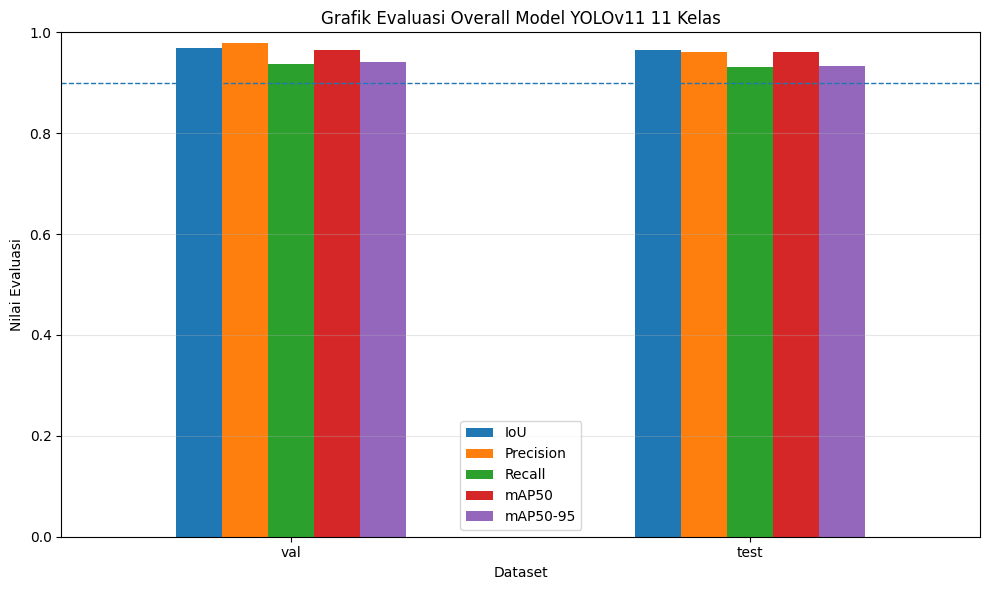

Grafik evaluasi overall tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/grafik_evaluasi_overall.png


In [20]:
# Cell 19 — Grafik Evaluasi Overall
plot_df = overall_df.set_index("Dataset")[
    [
        "IoU",
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95"
    ]
]

ax = plot_df.plot(kind="bar", figsize=(10, 6))

plt.title("Grafik Evaluasi Overall Model YOLOv11 11 Kelas")
plt.xlabel("Dataset")
plt.ylabel("Nilai Evaluasi")
plt.ylim(0, 1)
plt.axhline(y=0.90, linestyle="--", linewidth=1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

overall_graph_path = ARTIFACT_DIR / "grafik_evaluasi_overall.png"
plt.savefig(overall_graph_path, dpi=300)
plt.show()

print("Grafik evaluasi overall tersimpan di:", overall_graph_path)

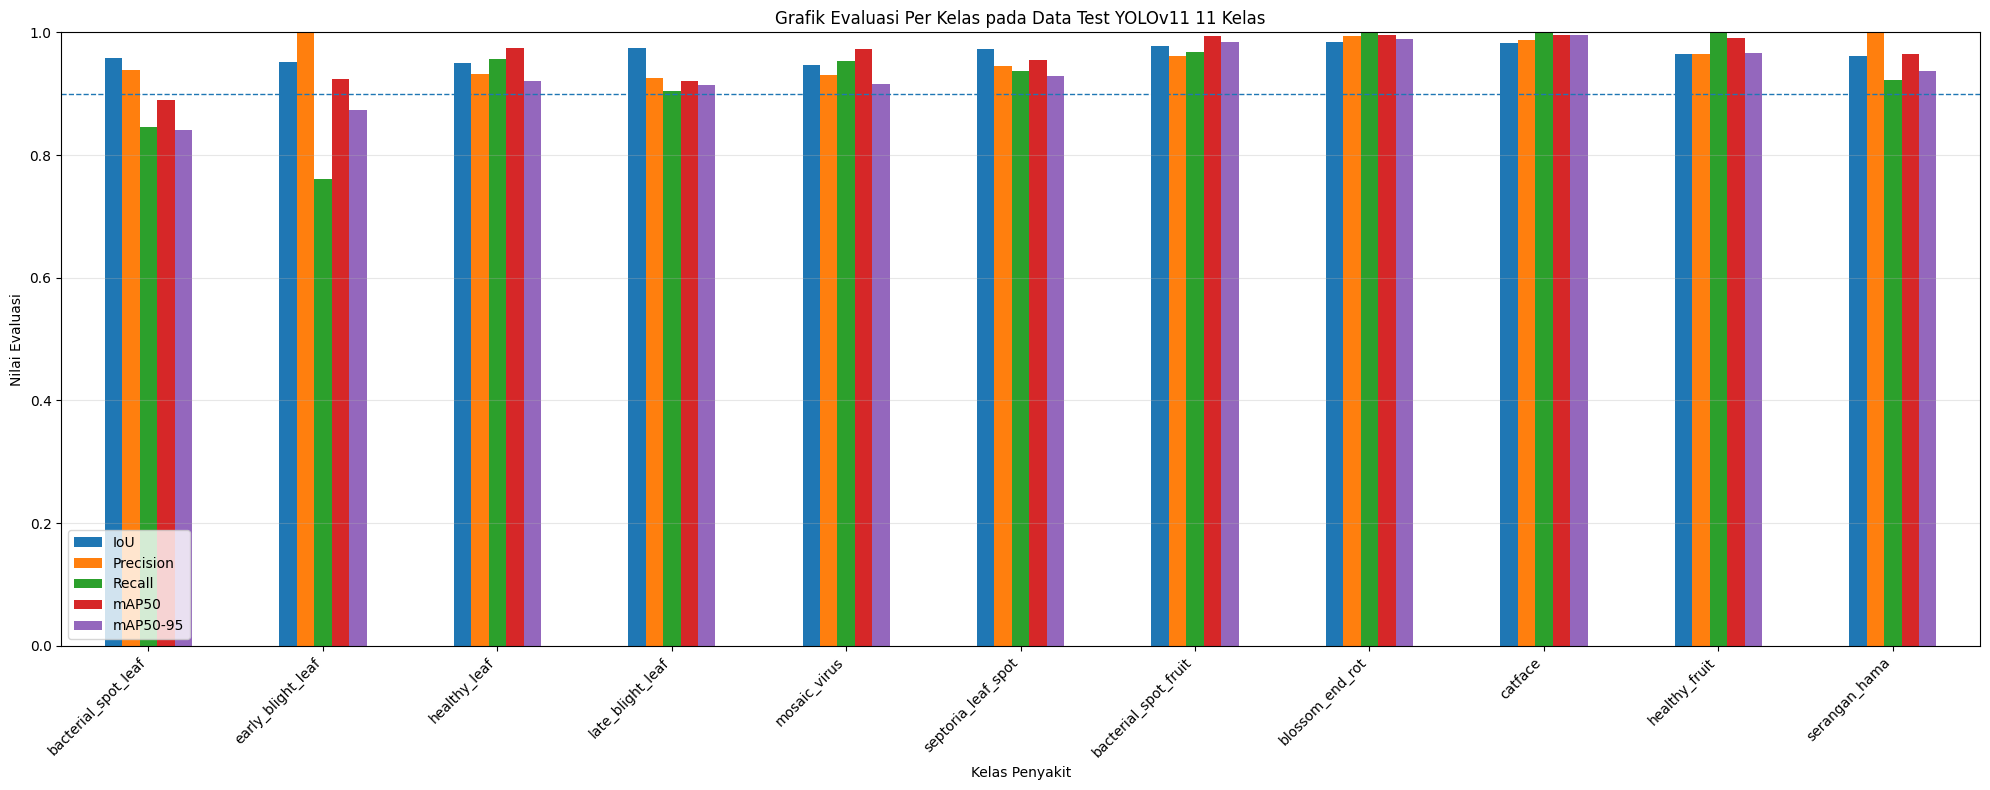

Grafik evaluasi per kelas test tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/grafik_evaluasi_perkelas_test.png


In [21]:
# Cell 20 — Grafik Evaluasi Per Kelas Data Test
test_class_df = per_class_metrics_df[per_class_metrics_df["Dataset"] == "test"].copy()

test_class_plot = test_class_df.set_index("class_name")[
    [
        "IoU",
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95"
    ]
]

ax = test_class_plot.plot(kind="bar", figsize=(20, 8))

plt.title("Grafik Evaluasi Per Kelas pada Data Test YOLOv11 11 Kelas")
plt.xlabel("Kelas Penyakit")
plt.ylabel("Nilai Evaluasi")
plt.ylim(0, 1)
plt.axhline(y=0.90, linestyle="--", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

per_class_graph_path = ARTIFACT_DIR / "grafik_evaluasi_perkelas_test.png"
plt.savefig(per_class_graph_path, dpi=300)
plt.show()

print("Grafik evaluasi per kelas test tersimpan di:", per_class_graph_path)

In [22]:
# Cell 21 — Analisis RGB Per Objek dan Per Kelas
from PIL import Image
import numpy as np
import pandas as pd

rgb_rows = []

for split in ["train", "val", "test"]:
    image_dir = dataset_path / "images" / split
    label_dir = dataset_path / "labels" / split

    for label_path in label_dir.glob("*.txt"):
        image_path = find_image_by_stem(image_dir, label_path.stem)

        if image_path is None:
            continue

        with Image.open(image_path) as img:
            img = img.convert("RGB")
            img_array = np.array(img)
            img_height, img_width, _ = img_array.shape

        with open(label_path, "r", encoding="utf-8") as f:
            lines = f.readlines()

        for line in lines:
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 5:
                continue

            class_id = int(float(parts[0]))

            if class_id < 0 or class_id >= len(class_names):
                print(f"Class ID tidak valid pada file {label_path}: {class_id}")
                continue

            x_center = float(parts[1])
            y_center = float(parts[2])
            box_width = float(parts[3])
            box_height = float(parts[4])

            x1 = int((x_center - box_width / 2) * img_width)
            y1 = int((y_center - box_height / 2) * img_height)
            x2 = int((x_center + box_width / 2) * img_width)
            y2 = int((y_center + box_height / 2) * img_height)

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(img_width, x2)
            y2 = min(img_height, y2)

            if x2 <= x1 or y2 <= y1:
                continue

            roi = img_array[y1:y2, x1:x2]
            mean_rgb = roi.reshape(-1, 3).mean(axis=0)

            rgb_rows.append({
                "split": split,
                "image": image_path.name,
                "class_id": class_id,
                "class_name": class_names[class_id],
                "mean_R": mean_rgb[0],
                "mean_G": mean_rgb[1],
                "mean_B": mean_rgb[2]
            })

rgb_df = pd.DataFrame(rgb_rows)

if len(rgb_df) == 0:
    raise ValueError("Data RGB kosong. Cek apakah gambar dan label tersedia.")

rgb_summary = rgb_df.groupby("class_name")[["mean_R", "mean_G", "mean_B"]].mean().reset_index()

print("Detail RGB:")
display(rgb_df.head())

print("Ringkasan RGB per kelas:")
display(rgb_summary)

rgb_detail_path = ARTIFACT_DIR / "rgb_analysis_detail.csv"
rgb_summary_path = ARTIFACT_DIR / "rgb_analysis_summary_per_class.csv"

rgb_df.to_csv(rgb_detail_path, index=False)
rgb_summary.to_csv(rgb_summary_path, index=False)

print("RGB detail tersimpan di:", rgb_detail_path)
print("RGB summary tersimpan di:", rgb_summary_path)

Detail RGB:


,split,image,class_id,class_name,mean_R,mean_G,mean_B
0,train,hardaug_early_blight_leaf_00208_sharpness_earl...,1,early_blight_leaf,105.712186,118.541886,87.567653
1,train,bacterial_spot_leaf_00011.jpg,0,bacterial_spot_leaf,132.664369,137.871262,92.318986
2,train,septoria_leaf_spot_01341.jpg,5,septoria_leaf_spot,109.861777,132.853885,101.885868
3,train,septoria_leaf_spot_01341.jpg,5,septoria_leaf_spot,120.342956,142.752680,108.824624
4,train,late_blight_leaf_00712.jpg,3,late_blight_leaf,120.724714,135.299481,119.500911


Ringkasan RGB per kelas:


,class_name,mean_R,mean_G,mean_B
0,bacterial_spot_fruit,126.314866,131.663170,66.087311
1,bacterial_spot_leaf,114.863912,118.782577,75.054773
2,blossom_end_rot,130.585639,109.642829,77.446115
3,catface,123.987361,121.708330,69.997916
4,early_blight_leaf,104.857696,115.382374,83.117637
5,healthy_fruit,143.964110,127.665238,64.832597
6,healthy_leaf,95.038337,116.371673,80.440286
7,late_blight_leaf,117.630892,123.141045,94.647084
8,mosaic_virus,100.597345,119.619904,84.414921
9,septoria_leaf_spot,106.955614,124.784212,101.112260


RGB detail tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/rgb_analysis_detail.csv
RGB summary tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/rgb_analysis_summary_per_class.csv


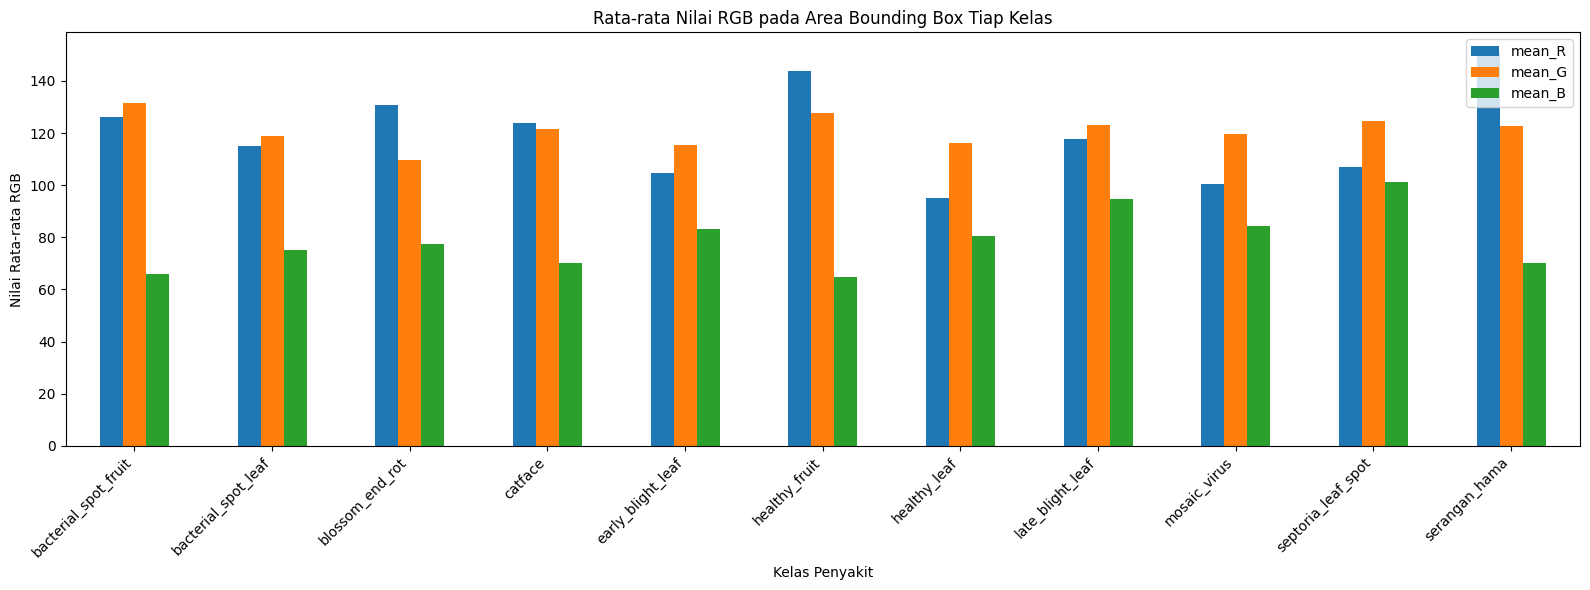

Grafik RGB tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/grafik_rgb_per_kelas.png


In [23]:
# Cell 22 — Grafik RGB Per Kelas
rgb_summary_plot = rgb_summary.set_index("class_name")

ax = rgb_summary_plot[["mean_R", "mean_G", "mean_B"]].plot(
    kind="bar",
    figsize=(16, 6)
)

plt.title("Rata-rata Nilai RGB pada Area Bounding Box Tiap Kelas")
plt.xlabel("Kelas Penyakit")
plt.ylabel("Nilai Rata-rata RGB")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

rgb_graph_path = ARTIFACT_DIR / "grafik_rgb_per_kelas.png"
plt.savefig(rgb_graph_path, dpi=300)
plt.show()

print("Grafik RGB tersimpan di:", rgb_graph_path)

In [24]:
# Cell 23 — Contoh Visualisasi RGB Satu Gambar Tiap Kelas
from IPython.display import Image as IPyImage, display

rgb_example_dir = ARTIFACT_DIR / "contoh_rgb_perkelas"
rgb_example_dir.mkdir(parents=True, exist_ok=True)

USE_BBOX_CROP = True


def find_sample_for_class(target_class_id):
    for split in ["test", "val", "train"]:
        image_dir = dataset_path / "images" / split
        label_dir = dataset_path / "labels" / split

        for label_path in label_dir.glob("*.txt"):
            image_path = find_image_by_stem(image_dir, label_path.stem)

            if image_path is None:
                continue

            with open(label_path, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()

                    if not line:
                        continue

                    parts = line.split()

                    if len(parts) != 5:
                        continue

                    class_id = int(float(parts[0]))

                    if class_id == target_class_id:
                        return {
                            "split": split,
                            "image_path": image_path,
                            "label_path": label_path,
                            "label_parts": parts
                        }

    return None


def crop_bbox_from_yolo(image_array, label_parts):
    img_height, img_width, _ = image_array.shape

    x_center = float(label_parts[1])
    y_center = float(label_parts[2])
    box_width = float(label_parts[3])
    box_height = float(label_parts[4])

    x1 = int((x_center - box_width / 2) * img_width)
    y1 = int((y_center - box_height / 2) * img_height)
    x2 = int((x_center + box_width / 2) * img_width)
    y2 = int((y_center + box_height / 2) * img_height)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_width, x2)
    y2 = min(img_height, y2)

    if x2 <= x1 or y2 <= y1:
        return image_array

    return image_array[y1:y2, x1:x2]


def create_rgb_visualization_for_class(class_id, class_name):
    sample = find_sample_for_class(class_id)

    if sample is None:
        print(f"Tidak ditemukan sampel untuk kelas: {class_name}")
        return None

    image_path = sample["image_path"]

    with Image.open(image_path) as img:
        img = img.convert("RGB")
        image_array = np.array(img)

    if USE_BBOX_CROP:
        visual_array = crop_bbox_from_yolo(image_array, sample["label_parts"])
        visual_title = f"{class_name}\nROI Bounding Box"
    else:
        visual_array = image_array
        visual_title = f"{class_name}\nFull Image"

    red_channel = visual_array[:, :, 0]
    green_channel = visual_array[:, :, 1]
    blue_channel = visual_array[:, :, 2]

    channels = [
        ("Red", red_channel, "Reds"),
        ("Green", green_channel, "Greens"),
        ("Blue", blue_channel, "Blues")
    ]

    fig, axes = plt.subplots(3, 3, figsize=(12, 9))

    for row_index, (channel_name, channel_data, cmap_name) in enumerate(channels):
        axes[row_index, 0].imshow(visual_array)
        axes[row_index, 0].set_title(f"RGB Image\n{visual_title}")
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(channel_data, cmap=cmap_name, vmin=0, vmax=255)
        axes[row_index, 1].set_title(f"{channel_name} Channel")
        axes[row_index, 1].axis("off")

        axes[row_index, 2].hist(channel_data.ravel(), bins=256, range=(0, 255))
        axes[row_index, 2].set_title(f"Histogram {channel_name}")
        axes[row_index, 2].set_xlim(0, 255)

    plt.suptitle(f"Analisis RGB - {class_name}", fontsize=14)
    plt.tight_layout()

    output_path = rgb_example_dir / f"{class_id}_{class_name}_rgb_visualization.png"
    plt.savefig(output_path, dpi=300)
    plt.close()

    return output_path


rgb_visual_paths = []

for class_id, class_name in enumerate(class_names):
    output_path = create_rgb_visualization_for_class(class_id, class_name)

    if output_path is not None:
        rgb_visual_paths.append(output_path)

print("Jumlah visualisasi RGB dibuat:", len(rgb_visual_paths))

for path in rgb_visual_paths:
    print(path)

Jumlah visualisasi RGB dibuat: 11
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/0_bacterial_spot_leaf_rgb_visualization.png
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/1_early_blight_leaf_rgb_visualization.png
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/2_healthy_leaf_rgb_visualization.png
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/3_late_blight_leaf_rgb_visualization.png
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/4_mosaic_virus_rgb_visualization.png
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/5_septoria_leaf_spot_rgb_visualization.png
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/6_bacterial_spot_fruit_rgb_visualization.png
/cont

In [25]:
# Cell 24 — Tampilkan Visualisasi RGB di Colab
for path in rgb_visual_paths:
    display(IPyImage(filename=str(path)))

Output hidden; open in https://colab.research.google.com to view.

In [26]:
# Cell 25 — Prediksi Gambar Test dan Simpan ke Colab
predict_results = model.predict(
    source=str(dataset_path / "images" / "test"),
    imgsz=IMGSZ,
    conf=0.25,
    save=True,
    project=str(RESULT_DIR),
    name=f"predict_test_{RUN_NAME}",
    exist_ok=True
)

predict_dir = RESULT_DIR / f"predict_test_{RUN_NAME}"

print("Hasil prediksi test tersimpan di:")
print(predict_dir)

Results saved to /content/YOLO_Tomat_Result/predict_test_final_yolo11m_tomat_11class_hardaug_v2
Hasil prediksi test tersimpan di:
/content/YOLO_Tomat_Result/predict_test_final_yolo11m_tomat_11class_hardaug_v2


In [27]:
# Cell 25B — Bersihkan Disk Sebelum Membuat ZIP
from pathlib import Path
import shutil

print("Cek disk sebelum pembersihan:")
!df -h

# Dataset hasil extract aman dihapus setelah training, evaluasi, RGB, dan prediksi selesai
dataset_extract_dir = Path("/content/tomat_dataset")

if dataset_extract_dir.exists():
    shutil.rmtree(dataset_extract_dir)
    print("Folder dataset hasil extract sudah dihapus:", dataset_extract_dir)
else:
    print("Folder dataset hasil extract tidak ditemukan atau sudah terhapus.")

# Bersihkan cache yang tidak penting
!rm -rf /root/.cache/pip
!rm -rf /root/.cache/torch
!rm -rf /root/.config/Ultralytics

print("\nCek disk setelah pembersihan:")
!df -h

Cek disk sebelum pembersihan:
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   86G   28G  76% /
tmpfs            64M     0   64M   0% /dev
shm              26G  296K   26G   1% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/nvme0n1p1  119G  112G  7.4G  94% /kaggle/input
tmpfs            27G  580K   27G   1% /var/colab
tmpfs            27G     0   27G   0% /proc/acpi
tmpfs            27G     0   27G   0% /proc/scsi
tmpfs            27G     0   27G   0% /sys/firmware
drive           113G   87G   26G  78% /content/drive
Folder dataset hasil extract sudah dihapus: /content/tomat_dataset

Cek disk setelah pembersihan:
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   72G   41G  64% /
tmpfs            64M     0   64M   0% /dev
shm              26G  296K   26G   1% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/nvme0n1p1  119G  112G  7.4G  94% /kaggle/input
tmpfs            27G  588K   27G   1% 

In [28]:
# Cell 26 — Buat ZIP Final di Colab
final_zip_path = Path(f"/content/hasil_final_{RUN_NAME}.zip")

if final_zip_path.exists():
    final_zip_path.unlink()

with zipfile.ZipFile(final_zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    # Masukkan semua artifact utama
    for file_path in ARTIFACT_DIR.rglob("*"):
        if file_path.is_file():
            arcname = file_path.relative_to(ARTIFACT_DIR)
            zipf.write(file_path, arcname=arcname)

    # Masukkan hasil prediksi test
    if predict_dir.exists():
        for file_path in predict_dir.rglob("*"):
            if file_path.is_file():
                arcname = Path("predict_test") / file_path.relative_to(predict_dir)
                zipf.write(file_path, arcname=arcname)

    # Masukkan output training penting
    training_results_dir = RUN_DIR

    if training_results_dir.exists():
        important_files = [
            "results.csv",
            "results.png",
            "confusion_matrix.png",
            "confusion_matrix_normalized.png",
            "PR_curve.png",
            "F1_curve.png",
            "P_curve.png",
            "R_curve.png",
            "labels.jpg",
            "labels_correlogram.jpg",
            "train_batch0.jpg",
            "train_batch1.jpg",
            "train_batch2.jpg",
            "val_batch0_labels.jpg",
            "val_batch0_pred.jpg",
            "val_batch1_labels.jpg",
            "val_batch1_pred.jpg",
            "val_batch2_labels.jpg",
            "val_batch2_pred.jpg"
        ]

        for important_name in important_files:
            source_file = training_results_dir / important_name
            if source_file.exists():
                zipf.write(source_file, arcname=Path("training_outputs") / important_name)

print("ZIP final tersimpan di Colab:")
print(final_zip_path)
print("Ukuran ZIP final:", round(final_zip_path.stat().st_size / (1024**2), 2), "MB")

ZIP final tersimpan di Colab:
/content/hasil_final_final_yolo11m_tomat_11class_hardaug_v2.zip
Ukuran ZIP final: 937.36 MB


In [29]:
# Cell 27 — Cek Isi ZIP Final
with zipfile.ZipFile(final_zip_path, "r") as zipf:
    file_list = zipf.namelist()

print("Jumlah file dalam ZIP:", len(file_list))

for item in file_list[:80]:
    print(item)

print("\nLokasi ZIP final:")
print(final_zip_path)

Jumlah file dalam ZIP: 366
grafik_rgb_per_kelas.png
rgb_analysis_detail.csv
best.pt
cek_target_90_persen_perkelas_test.csv
last.pt
cek_target_90_persen_overall.csv
grafik_evaluasi_overall.png
hasil_evaluasi_overall.csv
rgb_analysis_summary_per_class.csv
grafik_evaluasi_perkelas_test.png
hasil_evaluasi_perkelas.csv
contoh_rgb_perkelas/4_mosaic_virus_rgb_visualization.png
contoh_rgb_perkelas/0_bacterial_spot_leaf_rgb_visualization.png
contoh_rgb_perkelas/7_blossom_end_rot_rgb_visualization.png
contoh_rgb_perkelas/2_healthy_leaf_rgb_visualization.png
contoh_rgb_perkelas/10_serangan_hama_rgb_visualization.png
contoh_rgb_perkelas/9_healthy_fruit_rgb_visualization.png
contoh_rgb_perkelas/1_early_blight_leaf_rgb_visualization.png
contoh_rgb_perkelas/8_catface_rgb_visualization.png
contoh_rgb_perkelas/6_bacterial_spot_fruit_rgb_visualization.png
contoh_rgb_perkelas/3_late_blight_leaf_rgb_visualization.png
contoh_rgb_perkelas/5_septoria_leaf_spot_rgb_visualization.png
predict_test/blossom_end_r

In [30]:
# Cell 28 — Download ZIP Final ke Laptop
from google.colab import files

files.download(str(final_zip_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
# Cell 29 — Cek File Penting di ZIP
required_files = [
    "best.pt",
    "last.pt",
    "hasil_evaluasi_overall.csv",
    "hasil_evaluasi_perkelas.csv",
    "cek_target_90_persen_overall.csv",
    "cek_target_90_persen_perkelas_test.csv",
    "grafik_evaluasi_overall.png",
    "grafik_evaluasi_perkelas_test.png",
    "rgb_analysis_detail.csv",
    "rgb_analysis_summary_per_class.csv",
    "grafik_rgb_per_kelas.png"
]

with zipfile.ZipFile(final_zip_path, "r") as zipf:
    zip_items = zipf.namelist()

print("Cek file penting:")

for file_name in required_files:
    status = "ADA" if file_name in zip_items else "TIDAK ADA"
    print(f"{file_name}: {status}")

Cek file penting:
best.pt: ADA
last.pt: ADA
hasil_evaluasi_overall.csv: ADA
hasil_evaluasi_perkelas.csv: ADA
cek_target_90_persen_overall.csv: ADA
cek_target_90_persen_perkelas_test.csv: ADA
grafik_evaluasi_overall.png: ADA
grafik_evaluasi_perkelas_test.png: ADA
rgb_analysis_detail.csv: ADA
rgb_analysis_summary_per_class.csv: ADA
grafik_rgb_per_kelas.png: ADA
